# 05 Numerical Calculation of Magnetic Field

A second year physics experiment measures the force between two spherical magnets, a fixed one with diameter 25 mm and a moving one with diameter 12.5 mm.   and finds that at a vertical separation of 0.1m the repulsive force is 0.045 N.  The two magnets are aligned so that one is directly above the other, and the poles of the magnet are also aligned to the vertical.  

Calculate the force between two such magnets as a function of Magnetization, and then use the measured value to determine the magnetization of the magnets.  



## Physics
The Biot Savart law allows us to calculate the magnetic field $\vec{B}$ at a point $\vec{r}$ due to a small current element $Id\vec{l}$ at position $\vec{r}'$:
$$d\vec{B}(\vec{r})= \frac{\mu_0}{4\pi} \frac{Id\vec{l}\times(\vec{r}- \vec{r}')}{|\vec{r}-\vec{r}'|^3}$$

With the magnet used in the experiment, we know we have a sphere.  When we model this, we assume that it has uniform magnetization $\vec{M}=(0,0,M_0).$

There is a vector equation that relates the bound surface current density-  that is, that current due to the motion of electrons contained in the magnet to the magnetization and to the unit vector normal to a surface $\hat{n}$:
$$\vec{K_b}=\vec{M}\times\hat{n}$$
The direction of the vector is the direction of the current, so it is perpendicular to both $\vec{M}$ and $\hat{n}$. 

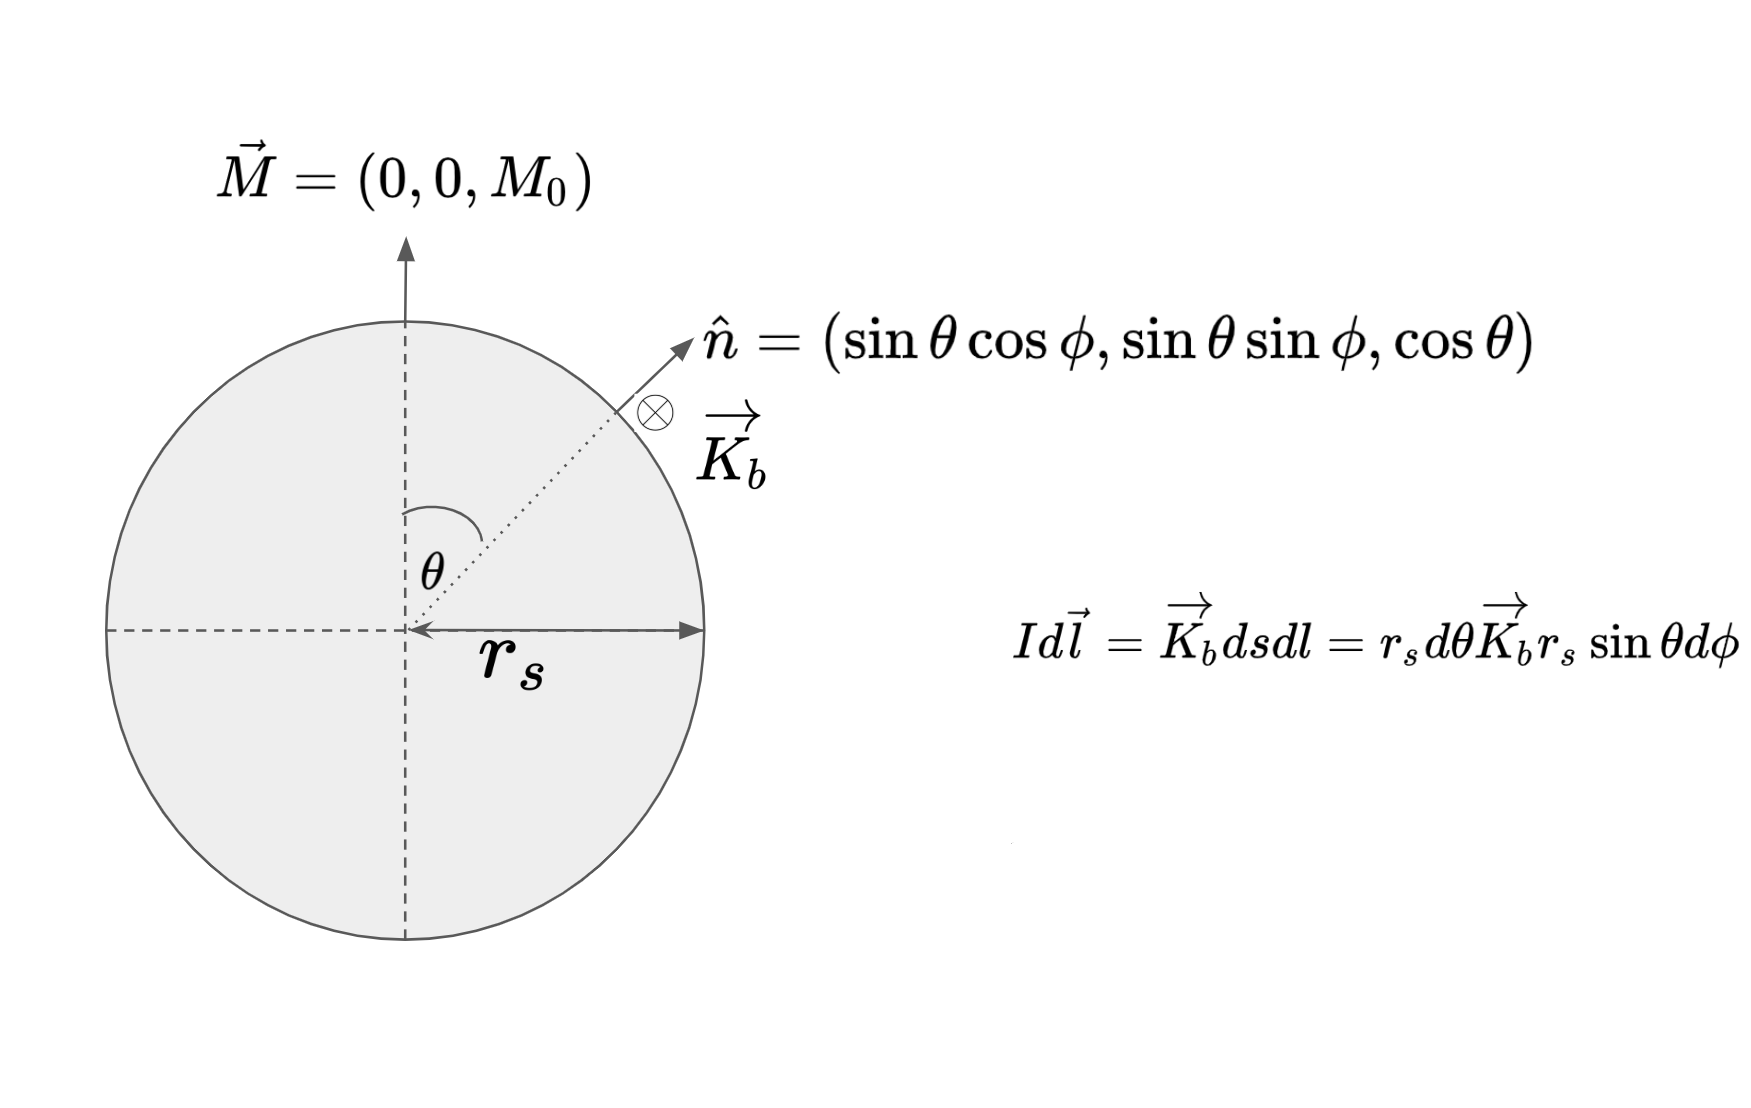


This lets us set up the integral:
$$\vec{B}(\vec{r})=\int_0^{2\pi}\int_0^\pi \frac {\mu_0}{4\pi} \frac{(\vec{M} \times \hat{n})\times(\vec{r}-\vec{r}')}{|\vec{r}-\vec{r}'|^3} r_s^2 \sin\theta d\theta d\phi $$

## Numerics
Notice that this is a vector equation- so it is actually 3 equations, one for each component of the magnetic field.  We set it up as two-dimensional integral, using scipy.integrate.dblquad.   We integrate each component separately.  

As an aside, we could also solve it as a nested ordinary differential equation

$$\frac{d^2\vec{B}(\vec{r})}{d\theta d\phi}= \frac {\mu_0}{4\pi} \frac{(\vec{M} \times \hat{n})\times(\vec{r}-\vec{r}')}{|\vec{r}-\vec{r}'|^3} r_s^2 \sin\theta $$

We will find $\frac{d\vec{B}(\vec{r})}{d\theta}$ by integrating over $\phi$ and then find $\vec{B}(\vec{r})$ by integrating over $\theta$.

I tried both- it turns out that dblquad is significantly faster than solving it as an ode.  

In addition, in this lecture we will use, without understanding, an interpolation routine.  That allows us to speed up considerably the time it takes to calculate a value based on a table of (slowly) calculated things.

## Validation

If we are far from the magnet, the field approaches that of a dipole.  We can look up the magnetic field of a dipole, which is most easily expressed in terms of a vector potential:
$$\vec{A}=\frac{\mu_0\vec{m}\times \hat{r}}{4\pi r^2}.$$

Here $\vec{m}$ is the magnetic moment, which has a magnitude $m=Ia$, where I is an enclosed current, and a is the area of a loop.  We will need to integrate the surface current over the sphere to calculate $m$, but note that this is the only integration involved.  

To get the B field, we need to use $\vec{B}=\vec{\nabla}\times \vec{A},$ and write a curl function, which does the numerical derivatives required.  

As an aside- we are doing significant effort to provide validation.  But without the validation we risk making a coding mistake that we never find.  For experiments, sometimes the data can provide validation- but one risks "tuning" your calculation to match the desired results, which has resulted in many problems in physics in the past. 


In [12]:
import numpy as np
import math
import timeit
from scipy.constants import mu_0,pi

mu0over4pi=mu_0/4/pi
M=np.array([0,0,1])  #  we don't know the magnetization, so we calculate it for for 1 and then scale at the end.
r_s=0.025/2 # m radius of base sphere
r2_s=0.0127/2 # m  radius of moving sphere

    
    

In [13]:
from scipy.integrate import dblquad
counter=0

def dB(phi,theta):  #Biot Savard to calculate field at position r due to current at phi,theta
    global counter
    counter=counter + 1
    n=np.array([math.sin(theta)*math.cos(phi),math.sin(theta)*math.sin(phi),math.cos(theta)])
    rprime=r-r_s*n
    value=mu0over4pi*np.cross(np.cross(M,n),rprime)/np.dot(rprime,rprime)**1.5*r_s**2*math.sin(theta)
#    print('value',value)
    return value

def B2(rpos):  #field at rpos
    global r #position where we want to know the field
    r=rpos
    sol=np.array([dblquad(lambda x,y: dB(x,y)[0],0,math.pi,0,2*math.pi)[0],
                  dblquad(lambda x,y: dB(x,y)[1],0,math.pi,0,2*math.pi)[0],
                  dblquad(lambda x,y: dB(x,y)[2],0,math.pi,0,2*math.pi)[0]])
    return sol

start = timeit.default_timer()

xsteps=np.linspace(0,0.03,31)
zsteps=np.linspace(0,0.15,151)
Bx=np.zeros((len(xsteps),len(zsteps)))
Bz=np.zeros((len(xsteps),len(zsteps)))
print(xsteps,zsteps,Bx,Bz)

for ix in range(len(xsteps)):
    for iz in range(len(zsteps)):
        B=B2(np.array([xsteps[ix],0,zsteps[iz]]))
        Bx[ix,iz]=B[0]
        Bz[ix,iz]=B[2]

print(Bx, Bz)
# All the program statements
stop = timeit.default_timer()
execution_time = stop - start

print("Program Executed in %f %d"%(execution_time,counter)) # It returns time in seconds

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03 ] [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1   0.101 0.102 0.103 0.104 0.105 0.106 0.107
 0.108 0.109 0.11  0.111 0.112 0.113 0.114 0.115 0.116 0.117 0.118 0.119
 0.12  0.121 0.122 0.123 0.124 0.125 0.126 0.127 0.128 0.129 0.13  0.131
 0.132 

In [29]:
from scipy.integrate import quad_vec
counter=0

def dBpt(phi,theta):  #Biot Savard to calculate field at position r due to current at phi,theta
    global counter
    counter=counter + 1
    n=np.array([math.sin(theta)*math.cos(phi),math.sin(theta)*math.sin(phi),math.cos(theta)])
    rprime=r-r_s*n
    value=mu0over4pi*np.cross(np.cross(M,n),rprime)/np.dot(rprime,rprime)**1.5*r_s**2*math.sin(theta)
#    print('value',value)
    return value[::2]

def dBt(theta):
    return quad_vec(dBpt,0,2*math.pi,args=theta)[0]
    
def B3(rpos):  #field at rpos
    global r #position where we want to know the field
    r=rpos
    return quad_vec(dBt,0,math.pi)[0]

start = timeit.default_timer()

xsteps=np.linspace(0,0.03,31)
zsteps=np.linspace(0,0.15,151)
Bxvv=np.zeros((len(xsteps),len(zsteps)))
Bzvv=np.zeros((len(xsteps),len(zsteps)))
print(xsteps,zsteps,Bx,Bz)

for ix in range(len(xsteps)):
    for iz in range(len(zsteps)):
        B=B3(np.array([xsteps[ix],0,zsteps[iz]]))
        Bxvv[ix,iz]=B[0]
        Bzvv[ix,iz]=B[1]

print('field due to quad_vec calc', Bxvv, Bzvv)
# All the program statements
stop = timeit.default_timer()
execution_time = stop - start

print("Program Executed in %f %d"%(execution_time,counter)) # It returns time in seconds

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03 ] [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1   0.101 0.102 0.103 0.104 0.105 0.106 0.107
 0.108 0.109 0.11  0.111 0.112 0.113 0.114 0.115 0.116 0.117 0.118 0.119
 0.12  0.121 0.122 0.123 0.124 0.125 0.126 0.127 0.128 0.129 0.13  0.131
 0.132 

In [30]:
import pickle
fields=(Bxvv,Bzvv,xsteps,zsteps)
with open('fieldvv.pickle','wb') as f:
    pickle.dump(fields,f)

In [14]:
import pickle
read=False
if(read):
    with open('field.pickle','rb')as f:
        Bx,Bz,xsteps,zsteps=pickle.load(f)
else:
    fields=(Bx,Bz,xsteps,zsteps)
    with open('field.pickle','wb') as f:
        pickle.dump(fields,f)

xsteps= [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03 ]
Z= [[ 0.   0.1  0.2 ... 14.8 14.9 15. ]
 [ 0.   0.1  0.2 ... 14.8 14.9 15. ]
 [ 0.   0.1  0.2 ... 14.8 14.9 15. ]
 ...
 [ 0.   0.1  0.2 ... 14.8 14.9 15. ]
 [ 0.   0.1  0.2 ... 14.8 14.9 15. ]
 [ 0.   0.1  0.2 ... 14.8 14.9 15. ]]


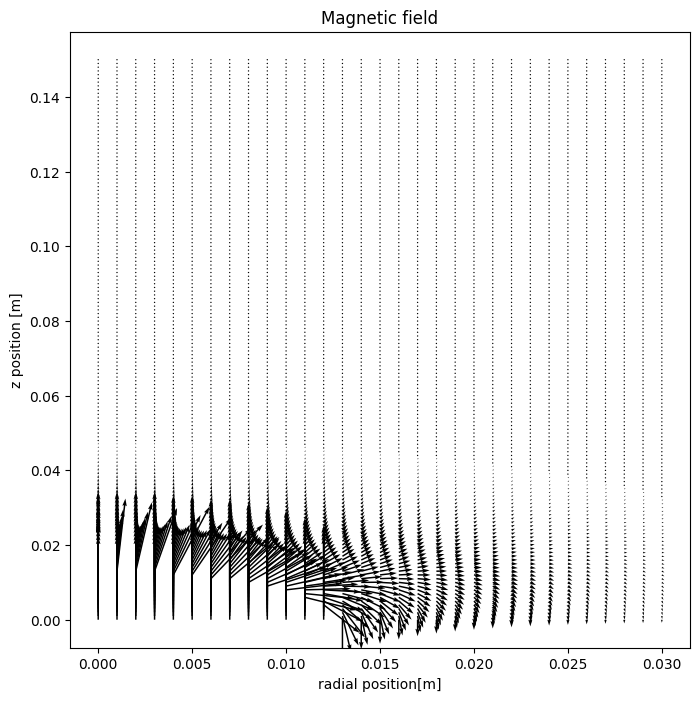

In [32]:
import matplotlib.pyplot as plt
%matplotlib inline
X,Z = np.mgrid[0:0.03:31j, 0:15:151j]
print('xsteps=', xsteps)
print('Z=',Z)
plt.figure(figsize=(8,8))
plt.title("Magnetic field")
plt.xlabel('radial position[m]')
plt.ylabel('z position [m]')
plt.quiver(xsteps,zsteps,Bx.transpose(),Bz.transpose())

In [16]:
#Set up an interpolation grid for the field.  This speeds up the following integration.

from scipy.interpolate import RectBivariateSpline
BzInt=RectBivariateSpline(xsteps,zsteps,Bz)
BrhoInt=RectBivariateSpline(xsteps,zsteps,Bx)

dd=(BzInt, BrhoInt)
with open('Interpolation.pickle','wb')as f:
    pickle.dump(dd,f)


Now, to find the force, we have 
$$d\vec{F}=I d\vec{l} \times \vec{B}$$
where now we are looking at the second ball.


We set up the integral exactly the same way:

$$\vec{F}=\int_0^{2\pi}\int_0^\pi \left((\vec{M}_2 \times \hat{n}_2)\times \vec{B}(\vec{r}_2+r_{2s}\hat{n}_2)\right) r_{2s}^2 d\theta \sin \theta d\phi $$

In [17]:
import pickle
with open('Interpolation.pickle','rb')as f:
    BzInt,BrhoInt=pickle.load(f)

    
def BInt(r):
    rho=math.sqrt(r[0]*r[0]+r[1]*r[1])
    Bfield=np.array([r[0]/rho*BrhoInt(rho,r[2])[0,0],r[1]/rho*BrhoInt(rho,r[2])[0,0],BzInt(rho,r[2])[0,0]] )
    return Bfield

In [19]:
from scipy.integrate import dblquad
M2=np.array([0,0,1.0])
counter=0
def dF(phi,theta):
    global counter
    counter=counter + 1
    n2=np.array([math.sin(theta)*math.cos(phi),math.sin(theta)*math.sin(phi),math.cos(theta)])
    rprime=r2+r2_s*n2
    value=np.cross(np.cross(M2,n2), BInt(rprime))*r2_s**2*math.sin(theta)
#    print('value',value)
    return value

def F(rpos):
    global r2
    r2=rpos
    sol=np.array([dblquad(lambda x,y: dF(x,y)[0],0,math.pi,0,2*math.pi)[0],
                  dblquad(lambda x,y: dF(x,y)[1],0,math.pi,0,2*math.pi)[0],
                  dblquad(lambda x,y: dF(x,y)[2],0,math.pi,0,2*math.pi)[0]])
    return sol

from numpy import genfromtxt
my_data = genfromtxt('Magnet_1.csv', delimiter=',',skip_header=7)

force=[]
for z in my_data[:,3]/1000+0.016:
    force.append(F(np.array([0,0,z])))
force=np.array(force)

In [20]:
for i in range(1,140):
    print('z=',f'{my_data[i,3]/1000+0.016:5.3f}','F=',f'{(my_data[i,4]-1.517)*9.8/1000.0:8.5}')


z= 0.135 F= -0.014073
z= 0.134 F= -0.014475
z= 0.133 F= -0.014876
z= 0.132 F= -0.015337
z= 0.131 F= -0.015778
z= 0.130 F= -0.016258
z= 0.129 F= -0.016748
z= 0.128 F= -0.017258
z= 0.127 F= -0.017787
z= 0.126 F= -0.018346
z= 0.125 F= -0.018914
z= 0.124 F= -0.019522
z= 0.123 F= -0.020149
z= 0.122 F= -0.020805
z= 0.121 F= -0.021452
z= 0.120 F= -0.022177
z= 0.119 F= -0.022903
z= 0.118 F= -0.023677
z= 0.117 F= -0.024471
z= 0.116 F= -0.025323
z= 0.115 F= -0.026186
z= 0.114 F= -0.027107
z= 0.113 F= -0.028048
z= 0.112 F= -0.029057
z= 0.111 F= -0.030096
z= 0.110 F= -0.031174
z= 0.109 F= -0.032301
z= 0.108 F= -0.033506
z= 0.107 F= -0.034751
z= 0.106 F= -0.036064
z= 0.105 F= -0.037436
z= 0.104 F= -0.038886
z= 0.103 F= -0.040386
z= 0.102 F= -0.041964
z= 0.101 F= -0.04361
z= 0.100 F= -0.045354
z= 0.099 F= -0.047158
z= 0.098 F= -0.049069
z= 0.097 F= -0.051078
z= 0.096 F= -0.053214
z= 0.095 F= -0.055419
z= 0.094 F=  -0.0578
z= 0.093 F= -0.06028
z= 0.092 F= -0.062936
z= 0.091 F= -0.065699
z= 0.090 F= -

Force at 10 cm as a function of magnetization.  Since the magnetization enters both the field and the surface current in the moving magnet, the force comes in as the square of the magnetization.  

The estimate magnetization is M0= 924520.2289420206


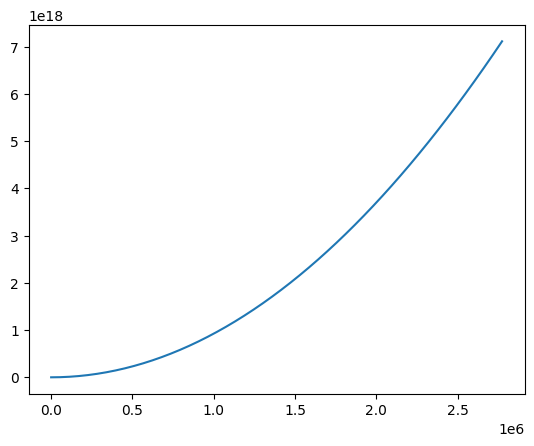

In [21]:
MeasuredForce=-0.045 #N
MSquared=MeasuredForce/(F(np.array([0,0,0.10]))[2])
mlist=np.linspace(0,np.sqrt(MSquared)*3)
plt.plot(mlist,np.sqrt(MSquared)*mlist**2)

M0=np.sqrt(MSquared)
print("The estimate magnetization is M0=",M0)

Text(0, 0.5, 'Force from integration-measurement [N]')

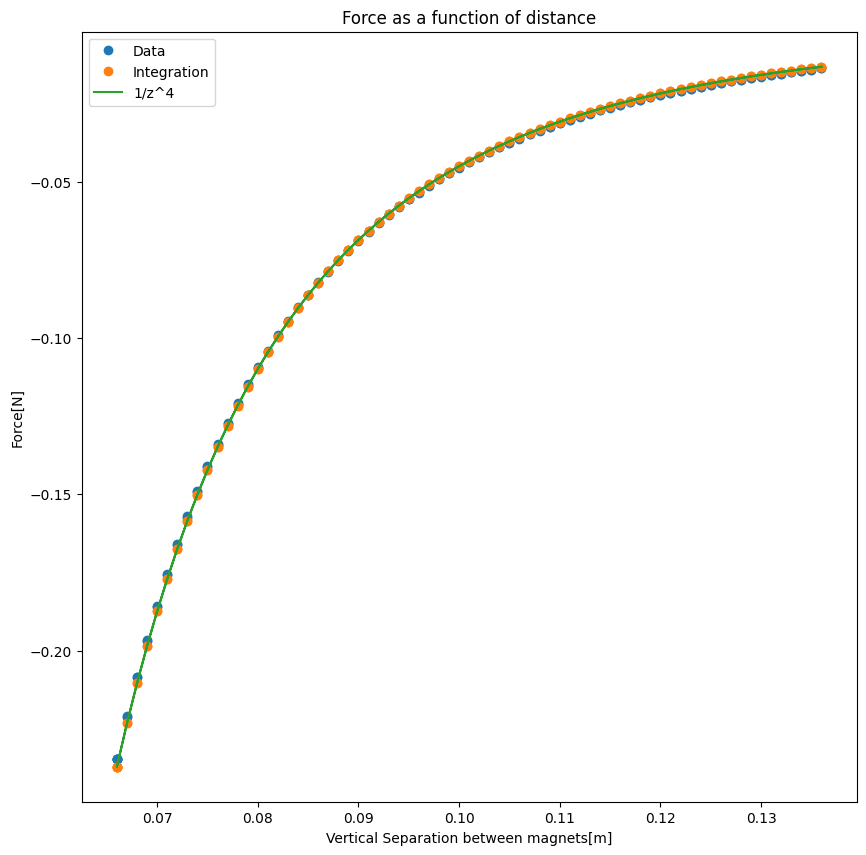

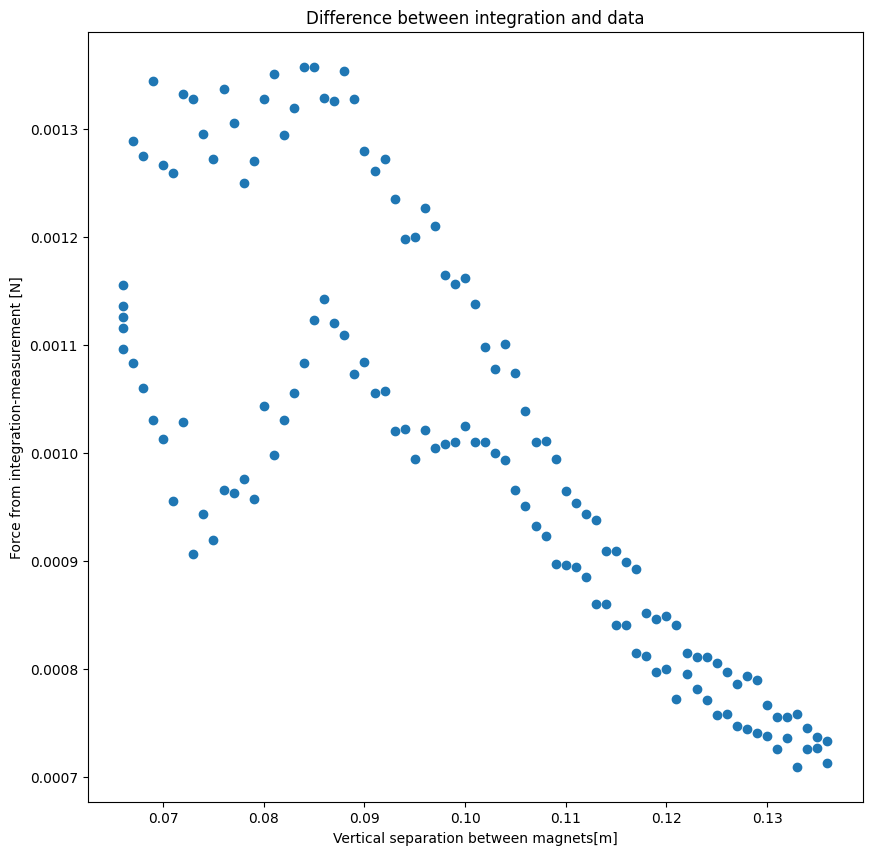

In [22]:
from numpy import genfromtxt
my_data = genfromtxt('Magnet_1.csv', delimiter=',',skip_header=7)
plt.figure(figsize=(10,10))
plt.title('Force as a function of distance')
plt.xlabel('Vertical Separation between magnets[m]')
plt.ylabel('Force[N]')
plt.plot(my_data[:,3]/1000+0.016,(my_data[:,4]-1.517)*9.8/1000.0,'o',label='Data')
plt.plot(my_data[:,3]/1000+0.016,force[:,2]*MSquared,'o',label='Integration')
plt.plot(my_data[:,3]/1000+0.016,-0.0000045/(my_data[:,3]/1000+0.016)**4,label=r'1/z^4')
plt.legend()
plt.figure(figsize=(10,10))
plt.plot(my_data[:,3]/1000+0.016,force[:,2]*0.842e12-(my_data[:,4]-1.517)*9.8/1000.0,'o')
plt.title(r'Difference between integration and data')
plt.xlabel('Vertical separation between magnets[m]')
plt.ylabel('Force from integration-measurement [N]')

## Validation
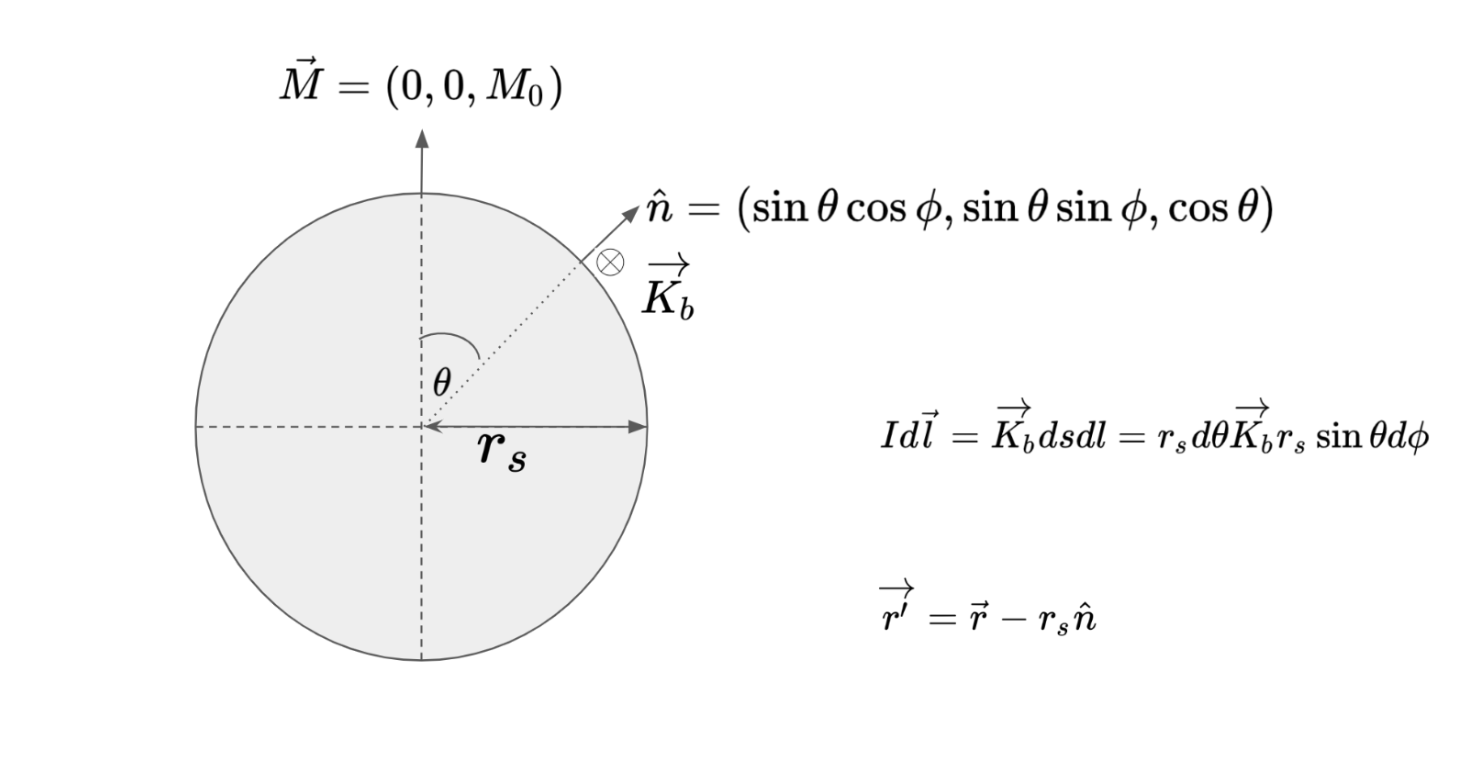


Our function $m=Ia=\pi r_s^2 \sin^2\theta r_s K_b d\theta$ with $K_b=\vec{M}\times \hat {n}=M_0 \sin\theta.$
Thus $dm=\pi r_s^3 \sin^3\theta M_0 d\theta$ which we need to integrate from top to bottom of the sphere to get our total magnetic moment.  This we can do analytically, but it is 234...

$$m=\int_0^\pi \pi r_s^3 \sin^3\theta M_0 d\theta$$

In [23]:
def mm(theta):
    return np.sin(theta)**3

from scipy.integrate import quad

integral=quad(mm,0,np.pi)
print('integral:',integral)
m=np.array([0,0,np.pi*r_s**3*M0*integral[0]])
print ('The magnetization is',m, 'Am**2')

integral: (1.333333333333333, 9.736847190659405e-14)
The magnetization is [0.         0.         7.56371344] Am**2


In [24]:
from scipy.constants import mu_0
def A(r):
    return mu_0*np.cross(m,r)/4/np.pi/np.linalg.norm(r)**3

In [25]:
def curl(A,r):
    '''Input is a vector function; we calculate the curl at vector position r using numerical derivatives'''
    dx=np.array([5e-6,0,0])
    dy=np.array([0,5e-6,0])
    dz=np.array([0,0,5e-6])
    rplus=r+dx
    rminus=r-dx
    dAdx=(A(rplus)-A(rminus))/(rplus-rminus)[0]
    rplus=r+dy
    rminus=r-dy
    dAdy=(A(rplus)-A(rminus))/(rplus-rminus)[1]
    rplus=r+dz
    rminus=r-dz    
    dAdz=(A(rplus)-A(rminus))/(rplus-rminus)[2]
    return np.array([dAdy[2]-dAdz[1], dAdz[0]-dAdx[2], dAdx[1]-dAdy[0]])
    

In [26]:
def Bvalidation(r):
    return curl(A,r)

In [27]:
r=np.array([.1,1,.1])
print (Bvalidation(r))
print (B2(r)*M0)

[ 2.15951334e-08  2.15951334e-07 -7.12639404e-07]
[ 2.15951334e-08  2.15951334e-07 -7.12639404e-07]
